# CNN chalenge

In this exercise, you will build a CNN to classify images from the Fashion MNIST dataset, train the model, evaluate its performance, and visualize predictions with a confusion matrix.

## Prepare the data

Load the Fashion MNIST dataset using Keras and display the first few images with their labels to get a sense of the data.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Task: Normalize the data to have pixel values between 0 and 1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 7us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step 
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Visualize 5 random images from the training set with their labels.

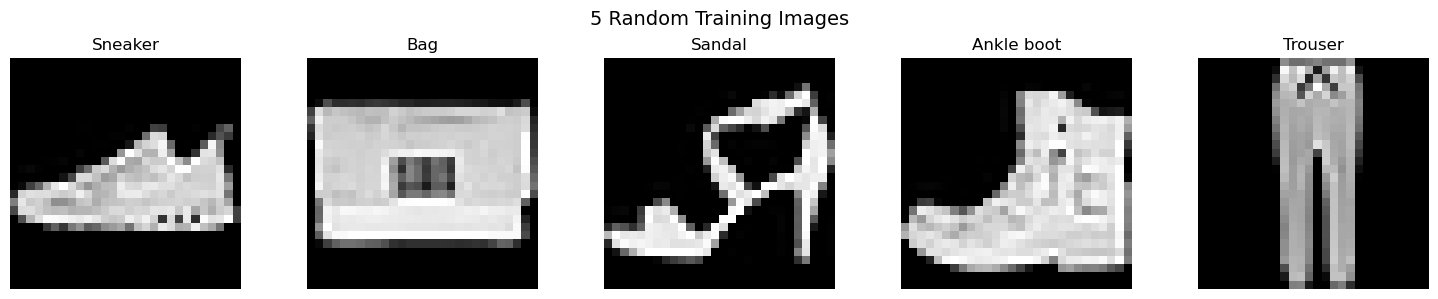

In [2]:
import numpy as np

# Class names for Fashion MNIST labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Pick 5 random indices
random_indices = np.random.choice(len(x_train), 5, replace=False)

# Plot
plt.figure(figsize=(15, 3))

for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[y_train[idx]])
    plt.axis('off')

plt.suptitle('5 Random Training Images', fontsize=14)
plt.tight_layout()
plt.show()

Reshape the data to include a channel dimension and confirm the new shape.

In [3]:
print("x_train shape:", x_train.shape)
print("x_test shape: ", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape:  (10000, 28, 28)


In [4]:
# Task: Reshape x_train and x_test to include the channel dimension

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape: ", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape:  (10000, 28, 28, 1)


## Build the CNN model

Create a CNN with at least two convolutional layers, followed by max pooling layers, and a dense output layer.

Rememeber the `Conv2D`, `MaxPooling2D`, `Flatten`, `Dropout` and `Dense`layers.

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense

model = Sequential([

    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Classifier
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')   # 10 classes = 10 fashion items
])

model.summary()

C:\Users\ricki\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Compile your model with an appropriate optimizer, loss function, and metric.

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train your model using model.fit(), setting a validation split of 20% and training for at least 10 epochs.

In [7]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.8060 - loss: 0.5306 - val_accuracy: 0.8579 - val_loss: 0.3822
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8631 - loss: 0.3733 - val_accuracy: 0.8848 - val_loss: 0.3159
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8807 - loss: 0.3265 - val_accuracy: 0.8908 - val_loss: 0.2948
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8904 - loss: 0.2979 - val_accuracy: 0.9029 - val_loss: 0.2675
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8955 - loss: 0.2807 - val_accuracy: 0.9018 - val_loss: 0.2665
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9029 - loss: 0.2616 - val_accuracy: 0.8986 - val_loss: 0.2692
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9072 - loss: 0.2483 - val_accuracy: 0.9108 - val_loss: 0.2466
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9103 -

## Evaluate the model

Evaluate your model on the test set and print the test accuracy.

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss:     {test_loss:.2f}")
print(f"Test Accuracy: {test_accuracy * 100:}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9082 - loss: 0.2487
Test Loss:     0.25
Test Accuracy: 90.82000255584717%


Use your model to predict the labels for the test set. Display 5 test images with their predicted and true labels.

In [9]:
# Task: Use model.predict() and display predictions

y_pred_probs = model.predict(x_test)

# Convert probabilities --> class with highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


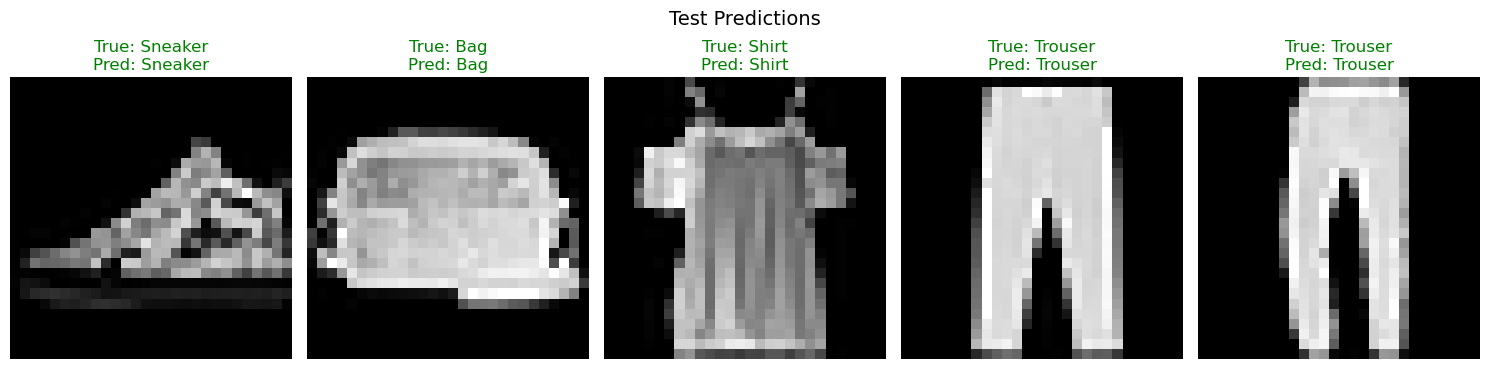

In [11]:
# display
random_indices = np.random.choice(len(x_test), 5, replace=False)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')

    true_label  = class_names[y_test[idx]]
    pred_label  = class_names[y_pred[idx]]

    color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle('Test Predictions', fontsize=14)
plt.tight_layout()
plt.show()

Construct a confusion matrix to visualize how well your model performed across different classes.

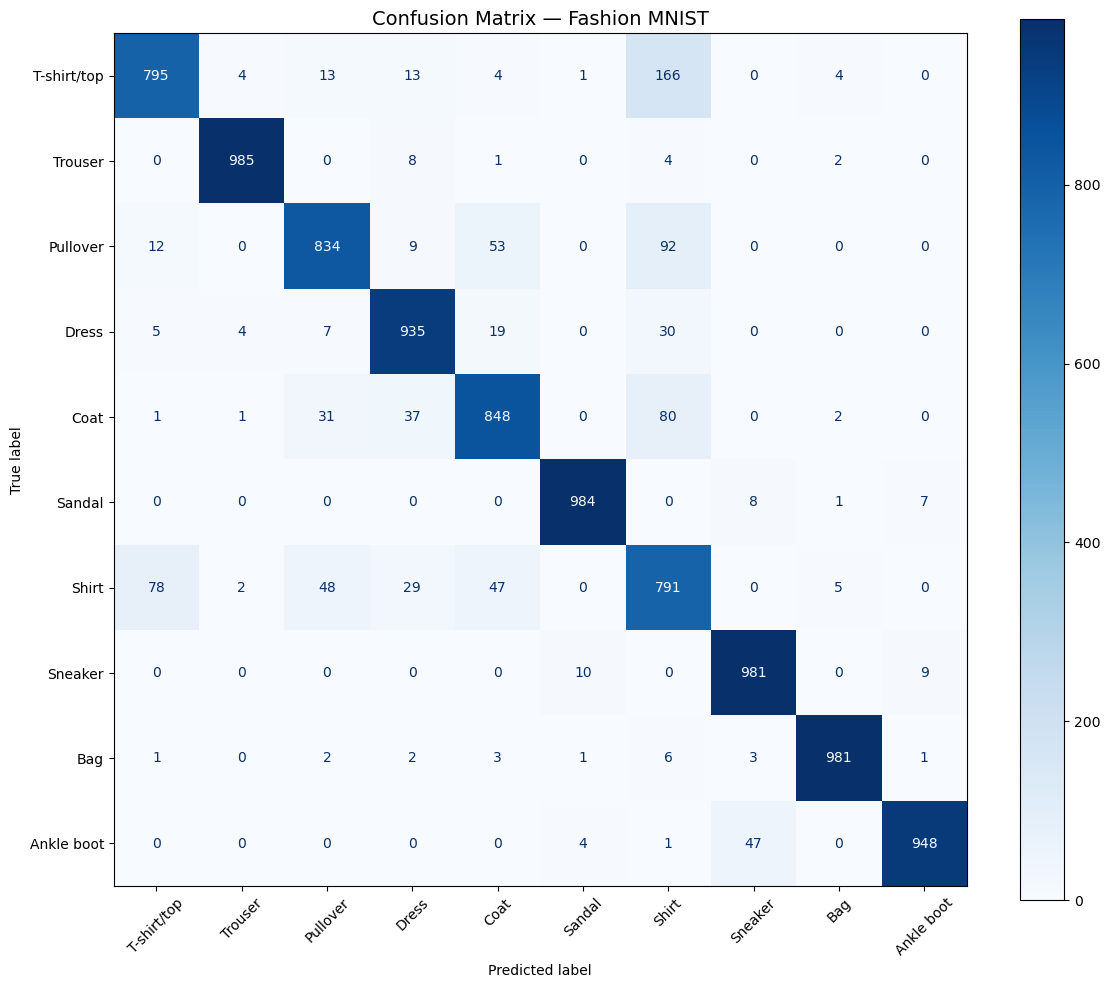

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Task: Create predictions and a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)

plt.title('Confusion Matrix — Fashion MNIST', fontsize=14)
plt.tight_layout()
plt.show()